# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff

## Task #1: Import the data and describe the sample

### Sort the stock data by date and print the number of stocks

In [9]:
df_1 = pd.read_csv("Data_PCLab1_Stock.csv", parse_dates=["Date"])
df_1 = df_1.sort_values("Date").set_index("Date")
df_1.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


In [10]:
print("The number of stocks is ", df_1.shape[1])

The number of stocks is  9


### Check if data contains any null values

In [11]:
pd.isna(df_1)

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,False,False,False,False,False,False,False,False,False
2012-01-13,False,False,False,False,False,False,False,False,False
2012-01-17,False,False,False,False,False,False,False,False,False
2012-01-18,False,False,False,False,False,False,False,False,False
2012-01-19,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
2020-08-05,False,False,False,False,False,False,False,False,False
2020-08-06,False,False,False,False,False,False,False,False,False
2020-08-07,False,False,False,False,False,False,False,False,False


In [14]:
percent_missing = df_1.isnull().sum() * 100 / len(df_1)
missing_value_df = pd.DataFrame({'percent_missing': percent_missing})
missing_value_df

,percent_missing
AAPL,0.0
BA,0.0
T,0.0
MGM,0.0
AMZN,0.0
IBM,0.0
TSLA,0.0
GOOG,0.0
sp500,0.0


There are **no missing values** for any of the columns in the dataset across the whole period.

### What is the average market value of the S&P500?

In [15]:
df_1.describe()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
count,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000
mean,140.819823,189.942700,35.162899,23.105743,915.665665,161.853001,259.600815,783.712512,2218.749554
std,70.827601,103.678586,3.207490,6.963847,697.838905,25.561938,210.988003,334.448057,537.321727
min,55.790001,67.239998,26.770000,7.140000,175.929993,94.769997,22.790001,278.481171,1278.040039
25%,89.165714,124.015000,33.040001,18.545000,316.490005,142.769997,184.595001,527.214416,1847.984985
50%,116.599998,142.419998,34.930000,23.780001,676.010010,156.949997,231.960007,737.599976,2106.629883
75%,175.019997,297.044998,37.419998,28.430000,1593.645019,185.974998,307.350006,1079.744995,2705.810059
max,455.609985,440.619995,43.470001,38.029999,3225.000000,215.800003,1643.000000,1568.489990,3386.149902


In [18]:
print("The average market value of S&P500 is: $", df_1['sp500'].mean())

The average market value of S&P500 is: $ 2218.7495540592868


### Which stock or index has the minimum dispersion in dollar value?

In [23]:
df_numeric = df_1.copy()

# Dispersion measures
dispersion_df = pd.DataFrame({
    "Variance": df_numeric.var(),
    "Standard Deviation": df_numeric.std(),
    "Range": df_numeric.max() - df_numeric.min(),
    "IQR": df_numeric.quantile(0.75) - df_numeric.quantile(0.25)
})

dispersion_df

,Variance,Standard Deviation,Range,IQR
AAPL,5016.549110,70.827601,399.819984,85.854283
BA,10749.249190,103.678586,373.379997,173.029998
T,10.287991,3.207490,16.700001,4.379997
MGM,48.495166,6.963847,30.889999,9.885000
AMZN,486979.137239,697.838905,3049.070007,1277.155014
IBM,653.412664,25.561938,121.030006,43.205002
TSLA,44515.937383,210.988003,1620.209999,122.755005
GOOG,111855.502794,334.448057,1290.008819,552.530579
sp500,288714.638185,537.321727,2108.109863,857.825074


In [38]:
min_disp_col = dispersion_df["Standard Deviation"].idxmin()
print(f"\nStock or Index with the minimum dispersion: {min_disp_col}")


Stock or Index with the minimum dispersion: T


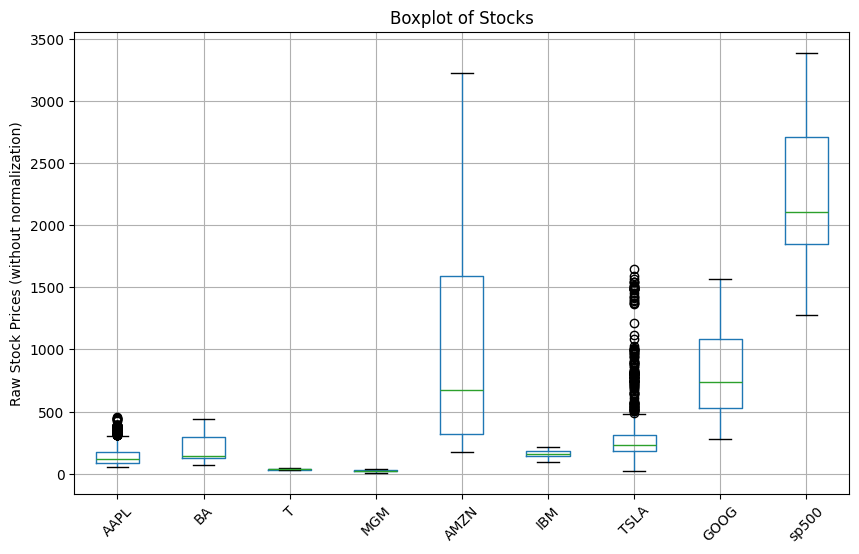

In [24]:
plt.figure(figsize=(10, 6))
df_numeric.boxplot()
plt.title("Boxplot of Stocks")
plt.ylabel("Raw Stock Prices (without normalization)")
plt.xticks(rotation=45)
plt.show()

As indicated in the boxplot above, it is visible that T stock has got minimum dispersion for raw stock prices (without normalization). This might be due to the fact that this stock has a lower price scale than the rest.

### What is the maximum price for Amazon stock over the specified time period?

In [31]:
max_idx = df_1['AMZN'].idxmax()         
max_val = df_1['AMZN'].max()            

print("The maximum value of Amazon over the specified time period is $", max_val, "noted on", max_idx.date())

The maximum value of Amazon over the specified time period is $ 3225.0 noted on 2020-08-06


## Task #2: Plot the data

### Define a function to plot the entire dataframe
The function takes in a dataframe as an input argument and does not return
anything back

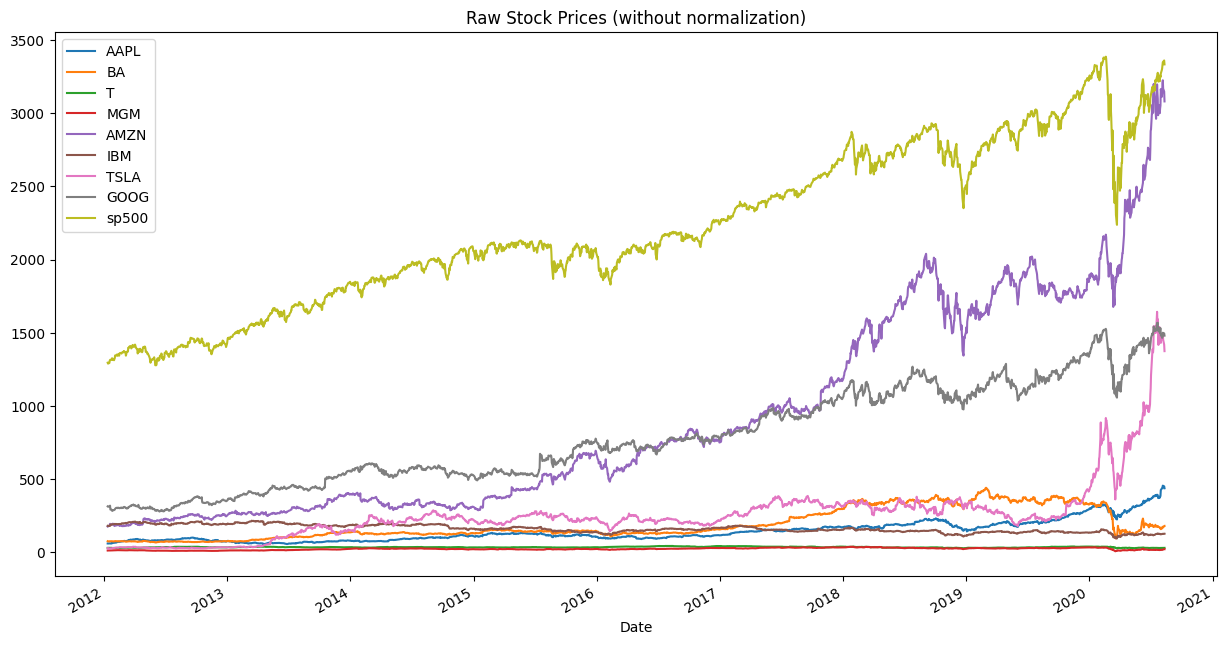

In [33]:
def plot(df):
    df_copy = df.copy()
    df_copy.plot(figsize=(15,8), title = 'Raw Stock Prices (without normalization)')

plot(df_1)

Across the whole period, Raw Stock Prices (without normalization) of S&P500 have been the highest. 

A sharp increase in prices can be noted for sp500 (S&P500), AMZN (Amazon), GOOG (Google), TSLA (Tesla) and AAPL (Apple) stocks around the first quarter of 2020.

## Task #3: Print out normalized (scaled) stock prices

### Define a function to normalize the prices based on the initial price
The function simply divides every stock by it’s price at the start date (i.e. : Date
= 2012-01-12)

In [34]:
def normalize_prices(df):
    df_norm = df.copy()
    start_row = df_norm.iloc[0]

    df_norm = df_norm / start_row
    return df_norm

In [35]:
df_1

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.130000,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.350000,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.250000,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.730000,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.800000,194.449997,180.520004,26.760000,318.590851,1314.500000
...,...,...,...,...,...,...,...,...,...
2020-08-05,440.250000,174.279999,29.850000,16.719999,3205.030029,125.449997,1485.020020,1473.609985,3327.770020
2020-08-06,455.609985,172.199997,29.840000,18.459999,3225.000000,126.120003,1489.579956,1500.099976,3349.159912
2020-08-07,444.450012,170.020004,30.020000,19.030001,3167.459961,124.959999,1452.709961,1494.489990,3351.280029


### Plot normalized data


In [39]:
normalized_df = normalize_prices(df_1)
normalized_df.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2012-01-13,0.996251,0.987949,0.998340,1.018137,1.014153,0.992301,0.806726,0.992615,0.995052
2012-01-17,1.007855,0.996424,1.004316,1.009893,1.032570,0.996954,0.941593,0.998317,0.998587
2012-01-18,1.018320,0.994040,1.006972,1.049464,1.076792,1.002880,0.949027,1.005193,1.009680
2012-01-19,1.015093,1.000662,1.009960,1.055235,1.105269,0.999834,0.947257,1.015771,1.014666


In [38]:
def plot(df):
    df_copy = df.copy()
    df_copy.plot(figsize=(15,8), title = 'Normalized Stock Prices')

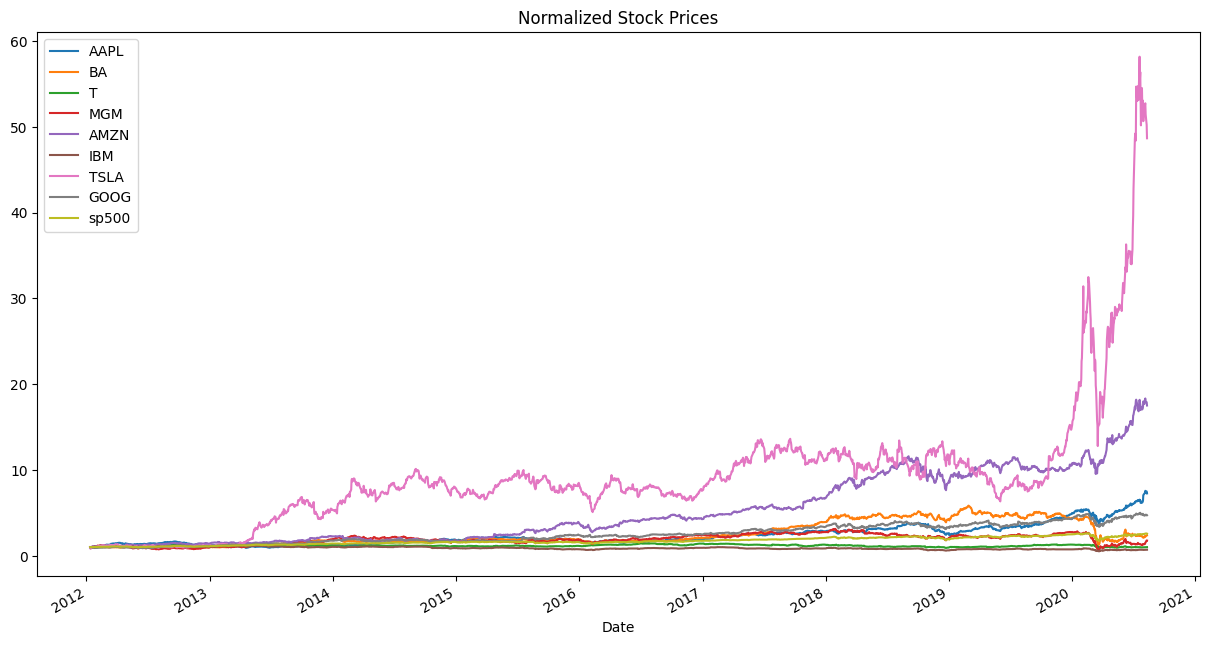

In [40]:
plot(normalized_df)

The normalization allowed to observe trends over the time period, removing differences in absolute stock price levels.

- TSLA (Tesla) shows the most dramatic growth, especially after 2019. 

- AMZN (Amazon) also displays strong long-term growth, steadily increasing over the years.

It is visible that the highest growth over the time period was achieved by tech-focused companies.

### **Optional:** Define a function to perform an interactive data plotting using plotly express

In [44]:
def interactive_plot(df):
    df_copy = df.copy()
    df_copy = df_copy.reset_index()
    
    # long-format
    df_long = df_copy.melt(id_vars="Date", var_name="Stock", value_name="Price")

    fig = px.line(
        df_long, 
        x="Date", 
        y="Price", 
        color="Stock",
        title="Normalized Stock Prices"
    )
    fig.show()

In [ ]:
iteractive_plot(normalized_df)

## Task #5 : Calculate stock returns

### Define a function to calculate stocks daily returns (for all stocks)
- Loop through each stock
- Loop through each row belonging to the stock

In [46]:
def daily_stock_returns(df):
    returns_df = pd.DataFrame(index=df.index) 
    
    for col in df.columns:
        returns = []
        for i in range(len(df)):
            if i == 0:
                returns.append(0)  # first day - no return
            else:
                prev_price = df[col].iloc[i-1]
                curr_price = df[col].iloc[i]
                daily_return = (curr_price - prev_price) / prev_price
                returns.append(daily_return)
        returns_df[col] = returns
    
    return returns_df

### Plot

<Axes: xlabel='Date'>

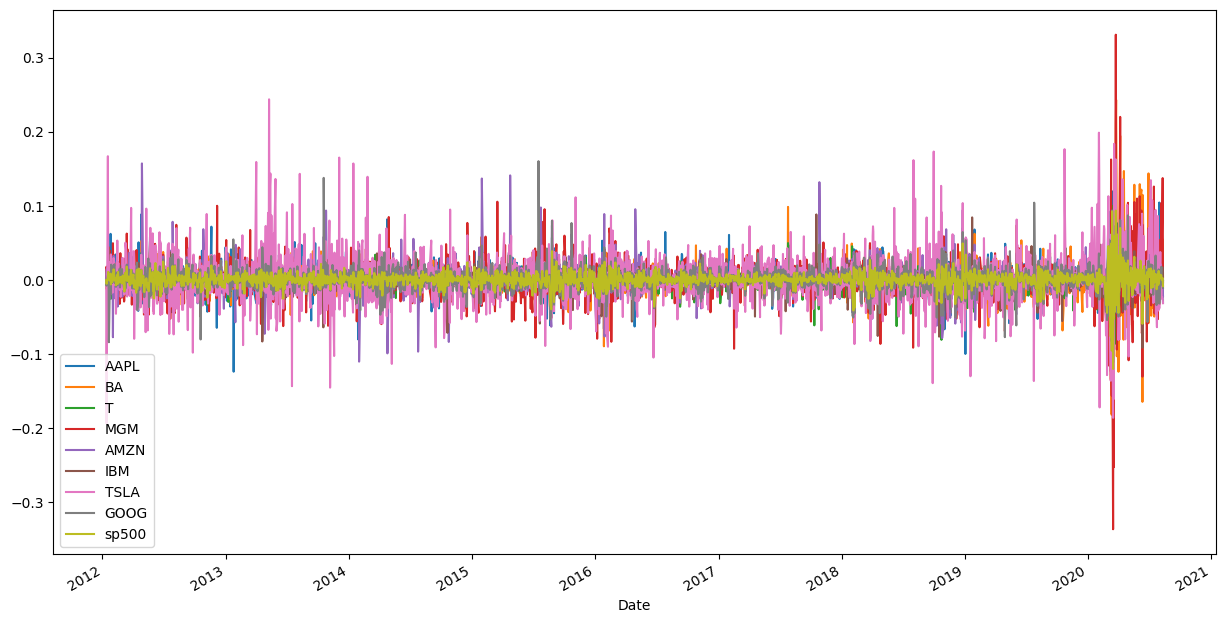

In [47]:
returns_df = daily_stock_returns(df_1)
returns_df.plot(figsize=(15,8))

Most returns are clustered around zero, reflecting small day-to-day fluctuations.

There are, however, **noticeable spikes** that represent large positive or negative returns. TSLA (Tesla) in particular exhibits **much higher volatility**. Around 2020, all stocks show **increased volatility**, consistent with the **COVID-19 outbreak**. In contrast to the other stocks, the **S&P 500 appears much smoother** and more stable, since diversification reduces overall volatility.

### Calculate the correlations between daily returns

In [48]:
correlation_matrix = returns_df.corr()
correlation_matrix

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
AAPL,1.000000,0.385250,0.341373,0.384089,0.410234,0.434534,0.288535,0.509125,0.657321
BA,0.385250,1.000000,0.401602,0.554229,0.267466,0.479264,0.250946,0.388048,0.641826
T,0.341373,0.401602,1.000000,0.340166,0.233145,0.484219,0.152515,0.353695,0.617463
MGM,0.384089,0.554229,0.340166,1.000000,0.309016,0.441631,0.311879,0.439142,0.631449
AMZN,0.410234,0.267466,0.233145,0.309016,1.000000,0.339589,0.310084,0.575284,0.539560
IBM,0.434534,0.479264,0.484219,0.441631,0.339589,1.000000,0.245609,0.458816,0.703935
TSLA,0.288535,0.250946,0.152515,0.311879,0.310084,0.245609,1.000000,0.322805,0.387921
GOOG,0.509125,0.388048,0.353695,0.439142,0.575284,0.458816,0.322805,1.000000,0.684572
sp500,0.657321,0.641826,0.617463,0.631449,0.539560,0.703935,0.387921,0.684572,1.000000


### Plot the correlation table as in heat-map

In [49]:
correlation_matrix.style.background_gradient(cmap="coolwarm")

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
AAPL,1.000000,0.385250,0.341373,0.384089,0.410234,0.434534,0.288535,0.509125,0.657321
BA,0.385250,1.000000,0.401602,0.554229,0.267466,0.479264,0.250946,0.388048,0.641826
T,0.341373,0.401602,1.000000,0.340166,0.233145,0.484219,0.152515,0.353695,0.617463
MGM,0.384089,0.554229,0.340166,1.000000,0.309016,0.441631,0.311879,0.439142,0.631449
AMZN,0.410234,0.267466,0.233145,0.309016,1.000000,0.339589,0.310084,0.575284,0.539560
IBM,0.434534,0.479264,0.484219,0.441631,0.339589,1.000000,0.245609,0.458816,0.703935
TSLA,0.288535,0.250946,0.152515,0.311879,0.310084,0.245609,1.000000,0.322805,0.387921
GOOG,0.509125,0.388048,0.353695,0.439142,0.575284,0.458816,0.322805,1.000000,0.684572
sp500,0.657321,0.641826,0.617463,0.631449,0.539560,0.703935,0.387921,0.684572,1.000000


As indicated by the positive correlations, most stocks move in the same direction as the broader market.

Most stocks have moderate positive correlations with the S&P 500, particularly IBM and Google.

### What are the top 2 stocks that are positively correlated with the S&P500?

In [ ]:
sp_corr = correlation_matrix["sp500"].drop("sp500")
sp_corr

AAPL    0.657321
BA      0.641826
T       0.617463
MGM     0.631449
AMZN    0.539560
IBM     0.703935
TSLA    0.387921
GOOG    0.684572
Name: sp500, dtype: float64

In [ ]:
print("The two stocks most correlated with S&P500 are:")
sp_corr.sort_values(ascending=False).head(2)

The two stocks most correlated with S&P500 are:


IBM     0.703935
GOOG    0.684572
Name: sp500, dtype: float64

IBM and GOOG (Google) stocks, as two stocks most correlated with the S&P500 index, have returns which tend to move very closely with the overall market.

### What is the correlation between Amazon and Boeing? Comment on your answer

In [ ]:
print("The correlation between AMZN and BA is:", correlation_matrix.loc["AMZN", "BA"])

The correlation between AMZN and BA is: 0.2674661380836475


The **correlation is relatively low (~0.27)**, which means that their stock returns don't move strongly together. 

While Amazon is a tech-oriented company, whose performance depends heavily on online retail and cloud computing, Boeing, on the other hand, is an aerospace company, whose stock is driven by airline demand and aircraft orders. Both companies **operate in different industries**, therefore their stock **prices are influenced by distinct factors**.

### What is the correlation between MGM and Boeing? Comment on your answer

In [ ]:
print("The correlation between AMZN and BA is:", correlation_matrix.loc["MGM", "BA"])

The correlation between AMZN and BA is: 0.5542294514206464


The **correlation is moderate (~0.55)**, which means that their stock returns tend to move in the same direction, although the relationship is not exceptionally strong. 

Both companies seem to be influenced by **similar factors** such as economic growth and travel demand. While MGM operates in the hospitality and entertainment industry, its stock price heavily depends on **consumer spending and travel demand**. Similarly for Boeing in the aerospace, its stock prices are heavily tied to **global travel and economic cycles**.

### Plot the histograms of daily returns and comment

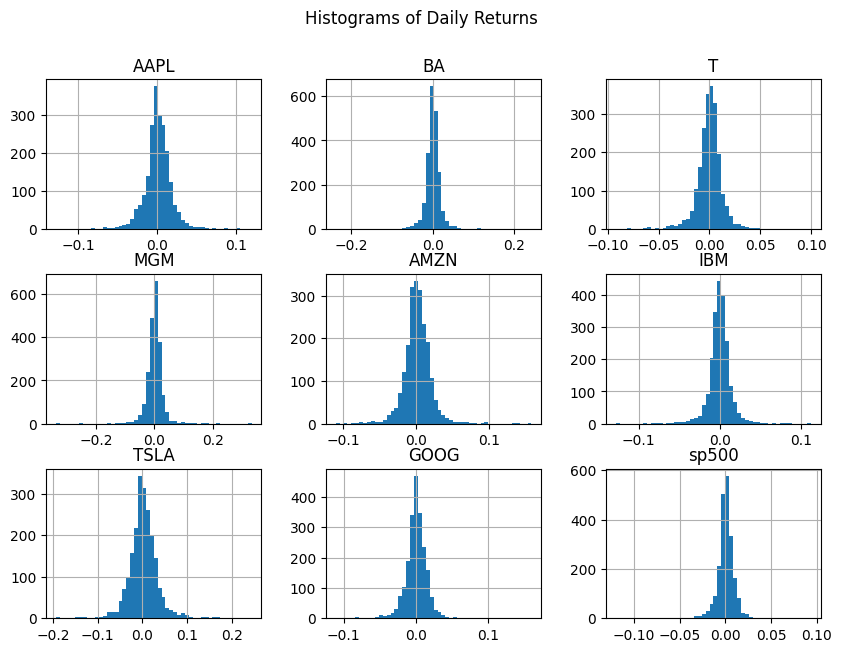

In [ ]:
returns_df.hist(bins=50, figsize=(10,7))
plt.suptitle("Histograms of Daily Returns")
plt.show()

All return distributions are **centered close to zero** (bell-shaped), reflecting that on average, **daily gains and losses balance out** in the short run.

Stocks such as TSLA (Tesla), MGM (MGM Resorts International) and BA (Boeing Co) display much **wider spreads, indicating higher volatility**. While the other stocks are more **narrowly centred, reflecting lower volatility**.

The S&P 500 distribution is narrower than most individual stocks.

The above-displayed histograms highlight the **trade-off between risk and return** - growth-oriented companies, such as Tesla, show wider dispersion - allowing for high potential gains but also higher losses, while diversified assets like S&P500 show lower risk with lower potential returns.

### **Optional**: Define a function to perform an interactive and fancy histograms plots using Plotly module (figure factory module)

In [74]:
def plot_interactive_histograms(df, bins=50):
    
    for col in df.columns:
        data = [df[col].values]

        fig = ff.create_distplot(
            hist_data=data,
            group_labels=[col],
            bin_size=1.0/bins,
            show_rug=False
        )

        fig.update_layout(
            title=f"Interactive Histogram of Daily Returns: {col}",
            xaxis_title="Daily Return",
            yaxis_title="Density",
            width=800,
            height=500,
            showlegend=False
        )

        fig.show()

In [75]:
plot_interactive_histograms(returns_df)

## Task #6 : Portfolio weights

### Write a function that will :
– Simulate 1000 portfolios with random weights

– Compute the return, the variance and the Sharpe ratio of each portfolio

– Return the maximum Sharpe ratio and its weights

In [ ]:
def simulate_portfolios(returns_df, num_portfolios=1000, rf=0.0, periods_per_year=252):
    # Annualized mean and covariance
    mean_returns = returns_df.mean() * periods_per_year
    cov_matrix = returns_df.cov() * periods_per_year

    rets, vols, sharpes, wts = [], [], [], []

    for _ in range(num_portfolios):
        # Random weights that sum to 1
        weights = np.random.random(len(returns_df.columns))
        weights /= weights.sum()

        # Portfolio annualized return/volatility
        port_ret = np.dot(weights, mean_returns.values)
        port_var = np.dot(weights.T, np.dot(cov_matrix.values, weights))
        port_vol = np.sqrt(port_var)

        # Sharpe ratio (annualized, rf in same units as mean_returns)
        sharpe = (port_ret - rf) / port_vol if port_vol != 0 else 0.0

        rets.append(port_ret)
        vols.append(port_vol)
        sharpes.append(sharpe)
        wts.append(weights)

    # Tangency (max Sharpe)
    best_idx = int(np.argmax(sharpes))
    best = {
        "sharpe": sharpes[best_idx],
        "return": rets[best_idx],
        "vol": vols[best_idx],
        "weights": np.array(wts[best_idx]),
    }
    cloud = {
        "returns": np.array(rets),
        "vols": np.array(vols),
        "sharpes": np.array(sharpes),
        "weights": np.array(wts),
        "mean_returns": mean_returns,
        "cov_matrix": cov_matrix
    }
    return best, cloud

In [ ]:
best, cloud = simulate_portfolios(returns_df, num_portfolios=1000, rf=0.0, periods_per_year=252)


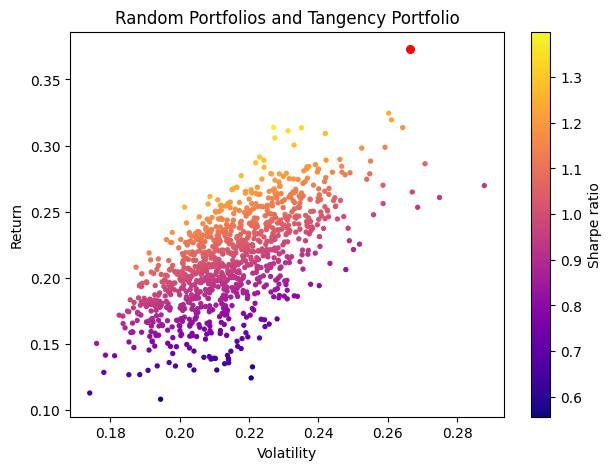

In [ ]:
plt.figure(figsize=(7,5))
sc = plt.scatter(
    cloud["vols"], cloud["returns"],
    c=cloud["sharpes"], cmap="plasma", s=8
)
plt.colorbar(sc, label="Sharpe ratio")

# Tangency portfolio as a big red dot
plt.scatter(
    best["vol"], best["return"],
    marker="o", s=30, c="red",  linewidth=1.0
)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Random Portfolios and Tangency Portfolio")
plt.show()


### What are the weights of your tangency portfolio? 


In [ ]:
weights_series = pd.Series(best["weights"], index=returns_df.columns).sort_values(ascending=False)
print("Max Sharpe ratio:", round(best["sharpe"], 4))
print("Tangency weights:")
print(weights_series.apply(lambda x: f"{x:.2%}"))

Max Sharpe ratio: 1.3994
Tangency weights:
AMZN     31.08%
TSLA     29.67%
AAPL     12.90%
BA        8.46%
sp500     7.51%
GOOG      6.13%
MGM       3.05%
IBM       1.08%
T         0.13%
dtype: object


### What would have been the performance of this portfolio over the sample period? Plot it!

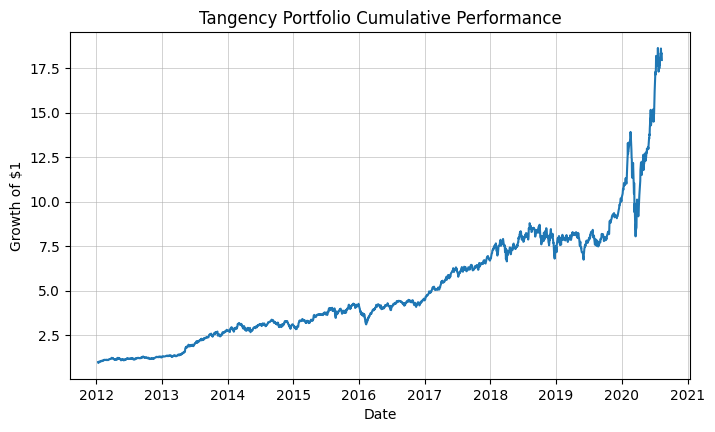

In [ ]:
tangency_daily = returns_df.dot(best["weights"])
cum_growth = (1 + tangency_daily).cumprod()

plt.figure(figsize=(8,4.5))
plt.plot(cum_growth.index, cum_growth.values)
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Tangency Portfolio Cumulative Performance")
plt.grid(True, linewidth=0.4)
plt.show()

### Comparing to a baseline portfolio with equal weights for each stock

In [ ]:
rf = 0.0
periods_per_year = 252

n = len(returns_df.columns)
ew_w = np.ones(n) / n

mean_ann = returns_df.mean() * periods_per_year
cov_ann  = returns_df.cov() * periods_per_year

# EW metrics
ew_ret = float(ew_w @ mean_ann.values)
ew_var = float(ew_w @ cov_ann.values @ ew_w)
ew_vol = np.sqrt(ew_var)
ew_sharpe = (ew_ret - rf) / ew_vol if ew_vol != 0 else 0.0

print("Equal-weight portfolio metrics:")
print(f"  Return (ann.):  {ew_ret:.4f}")
print(f"  Vol (ann.):     {ew_vol:.4f}")
print(f"  Sharpe (ann.):  {ew_sharpe:.4f}")
print("  Weights:")
for name, w in zip(returns_df.columns, ew_w):
    print(f"    {name}: {w:.2%}")


Equal-weight portfolio metrics:
  Return (ann.):  0.2138
  Vol (ann.):     0.2099
  Sharpe (ann.):  1.0184
  Weights:
    AAPL: 11.11%
    BA: 11.11%
    T: 11.11%
    MGM: 11.11%
    AMZN: 11.11%
    IBM: 11.11%
    TSLA: 11.11%
    GOOG: 11.11%
    sp500: 11.11%


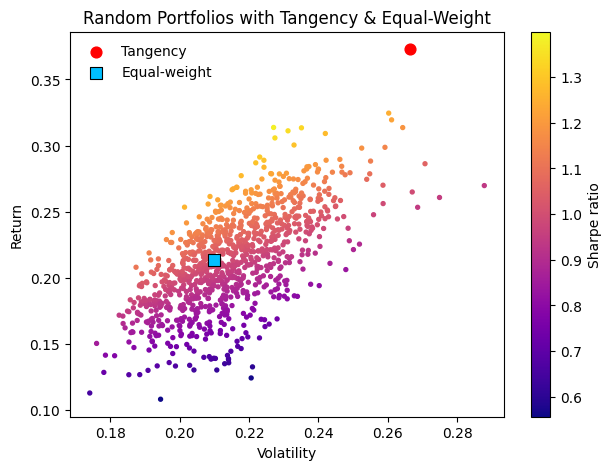

In [ ]:
plt.figure(figsize=(7,5))
sc = plt.scatter(
    cloud["vols"], cloud["returns"],
    c=cloud["sharpes"], cmap="plasma", s=8
)
plt.colorbar(sc, label="Sharpe ratio")

# Tangency portfolio (red dot)
plt.scatter(best["vol"], best["return"], marker="o", s=60, c="red", label="Tangency")

# Equal-weight portfolio (blue square)
plt.scatter(ew_vol, ew_ret, marker="s", s=70, c="deepskyblue", edgecolor="k", linewidth=0.8, label="Equal-weight")

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Random Portfolios with Tangency & Equal-Weight")
plt.legend(frameon=False)
plt.show()

### Optional : Define a function that finds the weights that minimize the variance for all possible level or return (i.e., that draw the efficient frontier). Plot it against the previous scatter plot

## Task #7 : Testing Portfolio Theory - Optional

Adding risk-free rates obtained from FRED to our dataset:

In [ ]:
df_rates = pd.read_csv("C:/Users/lasko/Downloads/DFF.csv")
df_rates["observation_date"] = pd.to_datetime(df_rates["observation_date"])

df = pd.merge(
    df_1,
    df_rates,
    left_on="Date",
    right_on="observation_date",
)

df = df.rename(columns={"DFF": "rate_free", "observation_date": "Date" })
cols = ["Date"] + [col for col in df.columns if col != "Date"]
df = df[cols]
df.head()

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500,rate_free
0,2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000,0.08
1,2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966,0.09
2,2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044,0.09
3,2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039,0.09
4,2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000,0.10


### Re-run Task #6 but only on the first part of the sample (2012-2016)

### Find out what are the optimal weights for this period

### Simulate your optimal portfolio on the second part of the sample (2016-end)
– How does it perform?
– Plot the expected (measured over the 1st period) vs. the realized return and volatility (over the second).

### Super optional : Let’s go a step further. Every year, you re-balance your portfolio based on last year data. What is your performance overall?